# Context Compaction Strategies

When an agent runs a multi-step task, every tool call adds messages to the context.
Without management, context grows until it hits the model's limit.

**Compaction strategies** trim messages *before* each LLM call in the agent's tool loop.
**Completion check hooks** prevent lazy early stopping by verifying the task is done
before allowing the agent to exit.

This notebook runs four configurations on the same code review task and compares
how compaction budget affects per-iteration productivity, file coverage, and
output quality — all at roughly the same total token cost.

Most agent harnesses (Claude Code, Cursor, Codex, etc.) use some form of review
hook to keep the agent working. The interesting question isn't *whether* to use
hooks, but how efficiently each iteration uses its context budget. Compaction
controls that tradeoff: too aggressive and the agent forgets prior work (thrashing),
too loose and the agent drags along stale context that crowds out new work.

The task analyzes the [handtracking](https://github.com/victordibia/handtracking)
repository — a self-contained Python project with ~44 `.py` files across multiple
directories. The repo is cloned automatically so anyone can reproduce the experiment.

All runs use Azure OpenAI (`gpt-4.1-mini`) with real API calls.
Each run is stochastic — exact numbers change between executions, but the patterns hold.
Results are persisted via `EvalResults` so you can re-run visualizations without
re-running agents. Delete `compaction_eval_results.json` to force fresh runs.

In [17]:
import os, subprocess
from pathlib import Path
 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv

from picoagents import Agent, LLMCompletionCheckHook
from picoagents.llm import AzureOpenAIChatCompletionClient
from picoagents.eval import (
    Dataset, EvalRunner, LLMEvalJudge, load_eval_results,
)
from picoagents.types import Task as EvalTask
from picoagents.tools._coding_tools import ReadFileTool, ListDirectoryTool
from picoagents.compaction import HeadTailCompaction
from picoagents.messages import ToolMessage

# Load Azure OpenAI credentials from picoagents/.env
load_dotenv(Path.cwd() / ".." / ".." / "picoagents" / ".env")
print("Ready.")

Ready.


## How Compaction Works

Compaction runs at one point in the agent's tool loop — **before each LLM call**:

```python
# Inside Agent.run(), in the tool loop:
if self.compaction:
    llm_messages = self.compaction.compact(llm_messages)
```

The compaction strategy respects **atomic groups** — an assistant message with `tool_calls`
is never separated from its `ToolMessage` results.

| Strategy | Keeps | Drops |
|----------|-------|-------|
| `NoCompaction` | Everything | Nothing |
| `HeadTailCompaction` | Head (system + task) + tail (recent work) | Middle messages |

HeadTail preserves both the task instructions (head) AND recent work (tail),
dropping only middle messages when the budget is exceeded. The head ratio
controls how much budget goes to preserving the original instructions vs
recent context.

## Experiment Setup

Task: exhaustive code review of the
[handtracking](https://github.com/victordibia/handtracking) repository
(~44 Python files across multiple directories including model training,
utilities, and protobuf modules).

Four runs, same task, same model:

| Run | Strategy | Budget | Hook | What it tests |
|-----|----------|--------|------|---------------|
| `NoCompaction` | None | — | Yes | Baseline — unbounded context growth |
| `HeadTail 8k` | HeadTail | 8,000 | Yes | Aggressive compaction + hook interaction |
| `HeadTail 8k (no hook)` | HeadTail | 8,000 | No | Aggressive compaction without hook pushback |
| `HeadTail 15k` | HeadTail | 15,000 | Yes | Moderate compaction budget |

The `HeadTail 8k (no hook)` config isolates the effect of the completion check hook.
Without it, the agent stops the first time it decides it's "done" — no pushback.

**Persistence knobs**: `max_iterations=50` gives agents room to work.
`LLMCompletionCheckHook(max_restarts=5)` pushes the agent back up to 5 times
when it tries to stop prematurely. Together these ensure agents run long enough
to reveal the true behavior of each compaction strategy, rather than stopping
early due to artificial limits.

The hook only fires when the agent voluntarily stops (no tool calls). It does NOT
fire when the agent hits `max_iterations` or on errors.

We use `AgentConfig` to declare each configuration and `EvalRunner` to
execute, score, and persist the results.

In [18]:
# Clone the handtracking repo (shallow) for a self-contained experiment
WORKSPACE = Path("/tmp/handtracking_repo")
if not WORKSPACE.exists():
    print("Cloning handtracking repo...")
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/victordibia/handtracking", str(WORKSPACE)],
        check=True, capture_output=True,
    )
    print(f"Cloned to {WORKSPACE}")
else:
    print(f"Using existing clone at {WORKSPACE}")

# Count .py files for ground-truth coverage metric
TOTAL_PY_FILES = len([
    f for f in WORKSPACE.rglob("*.py") if ".git" not in f.parts
])

# Read-only tools only. A full coding toolkit (Bash, Grep, WriteFile)
# would give the agent alternative paths to the same information,
# making it harder to isolate compaction effects. Two tools force a
# predictable list→read→list→read pattern that makes the sawtooth
# and thrashing patterns clearly visible.
tools = [
    ReadFileTool(workspace=WORKSPACE),
    ListDirectoryTool(workspace=WORKSPACE),
]

TASK = (
    "Review the handtracking repository source code. "
    "List every directory, read every .py file, and for each file "
    "document all classes and functions. Produce a summary table of "
    "all classes, top 10 code quality issues, and architecture recommendations."
)

# Model clients
agent_client = AzureOpenAIChatCompletionClient(
    model="gpt-4.1-mini",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
)
judge_client = AzureOpenAIChatCompletionClient(
    model="gpt-5.2-chat",
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
)

RESULTS_PATH = Path("compaction_eval_results.json")
print(f"Workspace: {WORKSPACE}")
print(f"Total .py files: {TOTAL_PY_FILES}")
print(f"Tools: {[t.name for t in tools]}")
print(f"Agent model: gpt-4.1-mini | Judge model: gpt-5.2-chat")

Using existing clone at /tmp/handtracking_repo
Workspace: /tmp/handtracking_repo
Total .py files: 44
Tools: ['read_file', 'list_directory']
Agent model: gpt-4.1-mini | Judge model: gpt-5.2-chat


In [19]:
# --- Task and Dataset ---
eval_task = EvalTask(
    name="Code Review", id="code_review", input=TASK,
    eval_criteria=["completeness", "actionability"],
    rubric={
        "completeness": (
            f"The repository contains {TOTAL_PY_FILES} .py files total. "
            "Score based on how many were ACTUALLY READ via read_file tool "
            "calls in the conversation (count the tool calls, do not trust "
            "the agent's claims about what it read). "
            "Scale linearly: 0% coverage=0, 100% coverage=10."
        ),
        "actionability": (
            "10=specific issues citing files, classes, and methods with "
            "concrete recommendations. "
            "5=generic observations without specific file references. "
            "0=no actionable findings produced."
        ),
    },
)
dataset = Dataset(name="compaction_strategies", tasks=[eval_task])

# --- Shared config ---
hook = LLMCompletionCheckHook(max_restarts=5)
SYSTEM_PROMPT = (
    "You are a senior software engineer doing a code review. "
    "You MUST use list_directory to discover files, then read_file to read "
    "EVERY .py file before writing your review. Do NOT guess or summarize "
    "file contents you haven't read. Work directory by directory: list it, "
    "read each .py file in it, then move to the next subdirectory. "
    "Do NOT call list_directory with recursive=True. "
    "Only list one directory at a time."
)
shared = dict(
    model_client=agent_client,
    tools=tools,
    max_iterations=50,
    instructions=SYSTEM_PROMPT,
)

# --- All agents ---
agents = [
    Agent(name="NoCompaction", description="No compaction",
          compaction=None, end_hooks=[hook], **shared),

    Agent(name="HeadTail 8k", description="HeadTail 8k budget",
          compaction=HeadTailCompaction(token_budget=8_000, head_ratio=0.2),
          end_hooks=[hook], **shared),

    Agent(name="HeadTail 8k (no hook)", description="HeadTail 8k, no hook",
          compaction=HeadTailCompaction(token_budget=8_000, head_ratio=0.2),
          **shared),

    Agent(name="HeadTail 15k", description="HeadTail 15k budget",
          compaction=HeadTailCompaction(token_budget=15_000, head_ratio=0.2),
          end_hooks=[hook], **shared),
]

# --- Isolation: sub-agent wrapped as a tool via as_tool() ---
sub_agent = Agent(
    name="code_reviewer",
    description="Reviews code in a directory by reading all .py files",
    instructions=SYSTEM_PROMPT,
    model_client=agent_client,
    tools=tools,
    compaction=HeadTailCompaction(token_budget=50_000, head_ratio=0.2),
    max_iterations=20,
)
coordinator = Agent(
    name="Isolation",
    description="Coordinator that delegates to a sub-agent",
    instructions=(
        "You are a senior software engineer doing a code review. "
        "Use the code_reviewer tool to delegate work. "
        "Delegate one directory at a time. For each delegation, pass a "
        "task like: 'List all files in <dir> using list_directory, then "
        "read each .py file with read_file. Document all classes and "
        "functions found.' After all directories are reviewed, synthesize "
        "a summary table of all classes, top 10 code quality issues, and "
        f"architecture recommendations. The workspace is: {WORKSPACE}"
    ),
    model_client=agent_client,
    tools=[sub_agent.as_tool()],
    end_hooks=[hook],
    max_iterations=15,
)
agents.append(coordinator)

# --- Run or Load from Cache ---
if RESULTS_PATH.exists():
    eval_results = load_eval_results(RESULTS_PATH)
    print(f"Loaded {len(eval_results.target_names)} cached results "
          f"from {RESULTS_PATH}")
else:
    judge = LLMEvalJudge(judge_client, name="gpt-5.2-chat-judge")
    runner = EvalRunner(judge=judge)
    eval_results = await runner.run(dataset, agents)
    eval_results.save(RESULTS_PATH)
    print(f"Saved results to {RESULTS_PATH}")

# --- Build convenience dict for visualization ---
task_id = eval_task.id
results = {}
for name in eval_results.target_names:
    tr = eval_results.get_result(name, task_id)
    if tr:
        results[name] = tr
        m = tr.metrics
        coverage = m.get('unique_files', 0) / TOTAL_PY_FILES * 100
        print(f"  {name}: {m.get('iterations', 0) or tr.iterations} LLM calls | "
              f"{m.get('tool_calls', 0) or tr.trajectory.usage.tool_calls} tool calls | "
              f"{m.get('unique_files', 0)}/{TOTAL_PY_FILES} files "
              f"({coverage:.0f}%) | "
              f"{tr.input_tokens:,} input tokens")

# --- Extract sub-agent tokens from ToolMessage.metadata ---
sub_agent_totals = {}
for name in eval_results.target_names:
    tr = eval_results.get_result(name, task_id)
    if tr is None:
        continue
    sub_tokens = 0
    sub_llm_calls = 0
    sub_tool_calls = 0
    for msg in tr.trajectory.messages:
        if isinstance(msg, ToolMessage) and msg.metadata:
            usage = msg.metadata.get("usage")
            if usage:
                sub_tokens += usage.get("tokens_input", 0)
                sub_llm_calls += usage.get("llm_calls", 0)
                sub_tool_calls += usage.get("tool_calls", 0)
    if sub_tokens > 0:
        sub_agent_totals[name] = {
            "tokens_input": sub_tokens,
            "llm_calls": sub_llm_calls,
            "tool_calls": sub_tool_calls,
        }
        print(f"  {name} sub-agents: {sub_llm_calls} LLM calls, "
              f"{sub_tokens:,} input tokens, "
              f"{sub_tool_calls} tool calls")

strategy_names = list(results.keys())
print(f"\n{len(results)} strategies ready.")

Loaded 5 cached results from compaction_eval_results.json
  NoCompaction: 50 LLM calls | 53 tool calls | 16/44 files (36%) | 915,591 input tokens
  HeadTail 8k: 50 LLM calls | 50 tool calls | 14/44 files (32%) | 276,390 input tokens
  HeadTail 8k (no hook): 32 LLM calls | 36 tool calls | 17/44 files (39%) | 144,136 input tokens
  HeadTail 15k: 46 LLM calls | 42 tool calls | 14/44 files (32%) | 402,102 input tokens
  Isolation: 15 LLM calls | 0 tool calls | 0/44 files (0%) | 39,759 input tokens
  Isolation sub-agents: 51 LLM calls, 79,065 input tokens, 48 tool calls

5 strategies ready.


## Context Growth

Each point is one LLM call, showing **actual API-reported input tokens**.
The structural patterns hold across runs; exact growth rates and batching behavior
are stochastic and will vary.

- **NoCompaction** grows monotonically — context never shrinks, every message accumulates.
- **HeadTail 8k** is *clamped flat* — budget so tight that compaction fires every call,
  keeping tokens near the budget line.
- **HeadTail 15k** should show the sawtooth — context grows until it exceeds the budget,
  compaction trims it back, then it grows again.

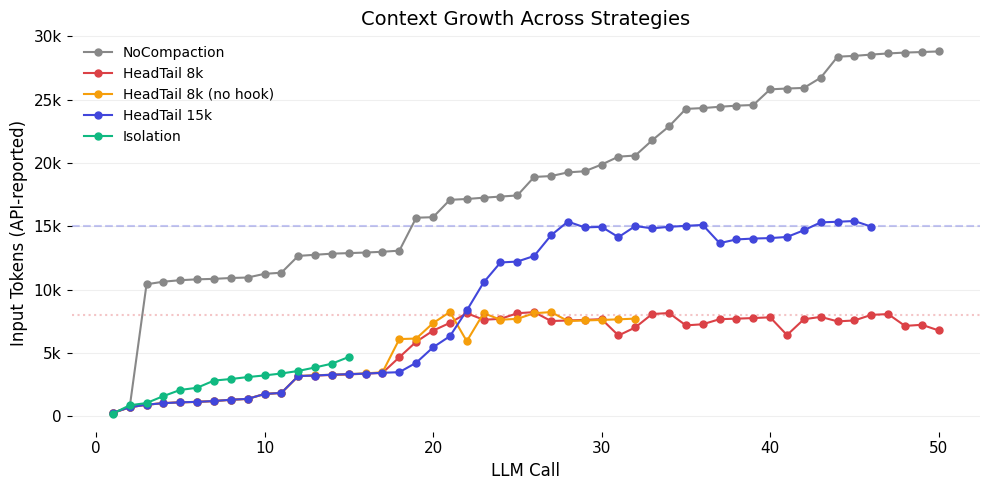

In [20]:
colors = {
    "NoCompaction": "#888888",
    "HeadTail 8k": "#DB4146",
    "HeadTail 8k (no hook)": "#F59E0B",
    "HeadTail 15k": "#4146DB",
    "Isolation": "#10B981",
}

fig, ax = plt.subplots(figsize=(10, 5))

for name in strategy_names:
    iters = results[name].metrics.get("iteration_details", [])
    if not iters:
        continue
    xs = [it["index"] + 1 for it in iters]
    ys = [it["input_tokens"] for it in iters]
    ax.plot(xs, ys, marker="o", markersize=5, linewidth=1.5,
            label=name, color=colors.get(name, "#333"))

# Budget lines without legend entries
ax.axhline(y=8_000, color="#DB4146", linestyle=":", alpha=0.3)
ax.axhline(y=15_000, color="#4146DB", linestyle="--", alpha=0.3)

ax.set_xlabel("LLM Call", fontsize=12)
ax.set_ylabel("Input Tokens (API-reported)", fontsize=12)
ax.set_title("Context Growth Across Strategies", fontsize=14)
ax.legend(fontsize=10, frameon=False)
ax.tick_params(labelsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("context_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Results and Quality

Token counts alone don't tell the story. An agent that uses fewer tokens but produces
garbage output isn't saving anything. The table below combines cost metrics with
LLM-as-judge quality scores and **ground-truth file coverage** (unique files actually
read via `read_file` out of the total .py files in the repo).

In [21]:
print(f"{'Strategy':<22} {'Input':>10} {'Output':>9} {'LLM':>5} "
      f"{'Tools':>6} {'Coverage':>10} {'Time':>6} "
      f"{'Comp':>5} {'Action':>7} {'Avg':>5}")
print("-" * 97)
for name in strategy_names:
    tr = results[name]
    m = tr.metrics
    dims = tr.score.dimensions
    unique = m.get('unique_files', 0)
    coverage = f"{unique}/{TOTAL_PY_FILES} ({unique/TOTAL_PY_FILES*100:.0f}%)"

    # For isolation, show coordinator + sub-agent tokens
    input_tok = tr.input_tokens
    sub = sub_agent_totals.get(name)
    if sub:
        total_tok = input_tok + sub["tokens_input"]
        tok_str = f"{input_tok:,}+{sub['tokens_input']:,}"
    else:
        tok_str = f"{input_tok:,}"

    # Fallback to trajectory usage when middleware metrics are absent
    llm_calls = m.get('iterations') or tr.iterations
    tool_calls = m.get('tool_calls') or tr.trajectory.usage.tool_calls

    print(
        f"{name:<22}"
        f" {tok_str:>10}"
        f" {tr.output_tokens:>9,}"
        f" {llm_calls:>5}"
        f" {tool_calls:>6}"
        f" {coverage:>10}"
        f" {tr.duration_ms / 1000:>5.0f}s"
        f" {dims.get('completeness', 0):>5.0f}"
        f" {dims.get('actionability', 0):>7.0f}"
        f" {tr.score.overall:>5.1f}"
    )

# Show isolation breakdown if present
if sub_agent_totals:
    print(f"\nIsolation token breakdown:")
    for name, sub in sub_agent_totals.items():
        coord = results[name].input_tokens
        total = coord + sub["tokens_input"]
        pct = coord / total * 100
        print(f"  {name}: coordinator {coord:,} ({pct:.0f}%) "
              f"+ sub-agents {sub['tokens_input']:,} "
              f"({sub['llm_calls']} LLM calls, "
              f"{sub['tool_calls']} tool calls) "
              f"= {total:,} total")

Strategy                    Input    Output   LLM  Tools   Coverage   Time  Comp  Action   Avg
-------------------------------------------------------------------------------------------------
NoCompaction              915,591     7,259    50     53 16/44 (36%)  1307s     5       7   6.0
HeadTail 8k               276,390     6,606    50     50 14/44 (32%)   122s     3       5   4.0
HeadTail 8k (no hook)     144,136     1,628    32     36 17/44 (39%)    46s     4       7   5.5
HeadTail 15k              402,102     9,452    46     42 14/44 (32%)   173s     3       7   5.1
Isolation              39,759+79,065     1,883    15      0  0/44 (0%)   835s     2       7   4.5

Isolation token breakdown:
  Isolation: coordinator 39,759 (33%) + sub-agents 79,065 (51 LLM calls, 48 tool calls) = 118,824 total


## Trace Analysis: Thrashing, Batching, and Redundancy

The numbers above don't tell the full story. Two strategies with the same LLM call count
can have completely different behavior. The trace analysis below reveals:

- **Tool call batching** — how many tools the model fires per LLM call
- **File access redundancy** — how many reads are duplicates (the thrashing signal)
- **Per-call breakdown** — the actual batch sequence showing explosive vs steady behavior

In [22]:
# --- Tool call batching (from iteration details) ---
def get_batch_sizes(name):
    """Extract per-LLM-call tool batch sizes from iteration details.
    
    Uses 'tool_call_count' (set by middleware from model response)
    rather than 'tool_calls' list (which tracks execution, not request).
    """
    iters = results[name].metrics.get("iteration_details", [])
    return [it.get("tool_call_count", 0) for it in iters]

print(f"{'Strategy':<20} {'LLM Calls':>10} {'Tool Calls':>11} {'Avg Batch':>10} {'Max Batch':>10}")
print("-" * 65)

batch_data = {}
for name in strategy_names:
    m = results[name].metrics
    batches = get_batch_sizes(name)
    batch_data[name] = batches
    non_zero = [b for b in batches if b > 0]
    avg_batch = sum(non_zero) / len(non_zero) if non_zero else 0
    max_batch = max(batches) if batches else 0
    print(
        f"{name:<20}"
        f" {m.get('iterations', 0):>10}"
        f" {m.get('tool_calls', 0):>11}"
        f" {avg_batch:>10.1f}"
        f" {max_batch:>10}"
    )

# --- File access redundancy ---
print(f"\n{'Strategy':<20} {'Reads':>7} {'Unique':>7} {'Duplicates':>11} {'Redundancy':>11}")
print("-" * 60)

for name in strategy_names:
    m = results[name].metrics
    total = m.get("total_file_reads", 0)
    unique = m.get("unique_files", 0)
    dupes = m.get("duplicate_reads", 0)
    ratio = m.get("duplicate_read_ratio", 0)
    pct = f"{ratio*100:.0f}%" if total > 0 else "—"
    print(f"{name:<20} {total:>7} {unique:>7} {dupes:>11} {pct:>11}")

# --- Per-call batch breakdown ---
print("\n--- Per-Call Tool Batches ---")
for name in strategy_names:
    batches = batch_data.get(name, [])
    if batches:
        batch_str = ", ".join(str(b) for b in batches)
        print(f"  {name}: [{batch_str}]")

Strategy              LLM Calls  Tool Calls  Avg Batch  Max Batch
-----------------------------------------------------------------
NoCompaction                 50          53        1.2          7
HeadTail 8k                  50          50        1.1          2
HeadTail 8k (no hook)         32          36        1.2          3
HeadTail 15k                 46          42        1.1          2
Isolation                    15           0        1.0          1

Strategy               Reads  Unique  Duplicates  Redundancy
------------------------------------------------------------
NoCompaction              22      16           6         27%
HeadTail 8k               31      14          17         55%
HeadTail 8k (no hook)      20      17           3         15%
HeadTail 15k              26      14          12         46%
Isolation                  0       0           0           —

--- Per-Call Tool Batches ---
  NoCompaction: [1, 7, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 

## Judge Reasoning

The most useful output from evaluation: *why* each strategy scored the way it did.

In [23]:
for sname in strategy_names:
    tr = results[sname]
    s = tr.score
    dims = " | ".join(f"{k}={v:.0f}" for k, v in s.dimensions.items())
    print(f"\n{'='*65}")
    print(f"  {sname}  |  avg {s.overall:.1f}/10  |  {dims}")
    print(f"{'='*65}")
    for criterion, reasoning in s.reasoning.items():
        val = s.dimensions.get(criterion, "?")
        print(f"\n  [{criterion}] = {val}/10")
        words = reasoning.split()
        line = "    "
        for w in words:
            if len(line) + len(w) + 1 > 72:
                print(line)
                line = "    " + w
            else:
                line += (" " + w) if line.strip() else ("    " + w)
        if line.strip():
            print(line)


  NoCompaction  |  avg 6.0/10  |  completeness=5 | actionability=7

  [completeness] = 5.0/10
        The repository contains 44 .py files. Based strictly on the
    conversation log, there were approximately 22 read_file tool calls
    in total (including repeated reads of the same files). This
    corresponds to about 50% coverage when scored linearly as
    instructed. The agent did not read every .py file in the repository.

  [actionability] = 7.0/10
        The agent provided a concrete list of issues and recommendations
    that cite specific files, functions, and classes (e.g.,
    dispaly_boxes typo in handtrack/utils/display_utils.py,
    multiprocessing issues in detect_multi_threaded.py, duplicated
    dataset scripts). While some repetition and over-assertion occurred,
    the findings are largely specific and actionable rather than
    generic.

  HeadTail 8k  |  avg 4.0/10  |  completeness=3 | actionability=5

  [completeness] = 3.0/10
        The repository is stated t

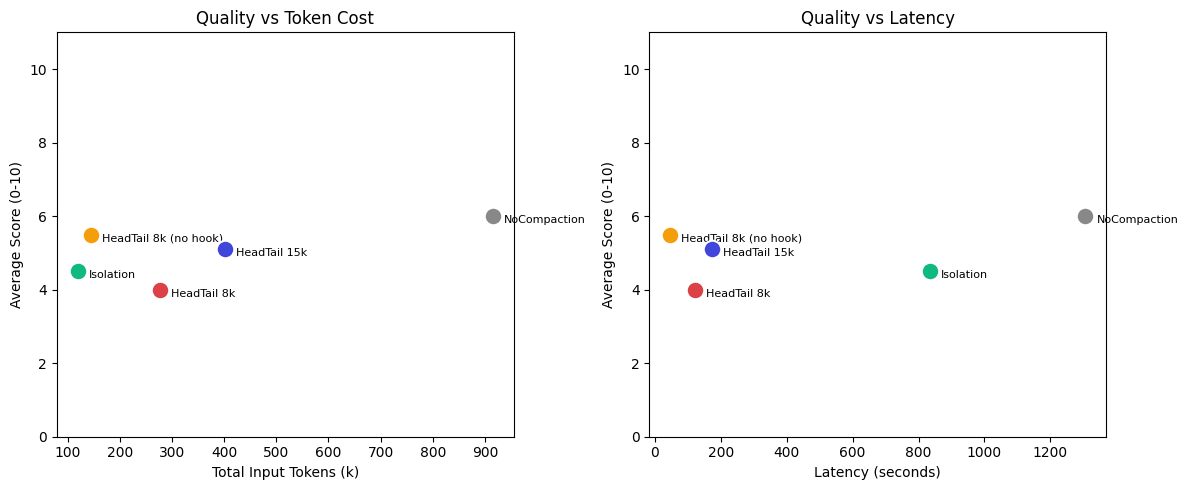

In [24]:
# --- Pareto: Quality vs Cost and Quality vs Latency ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def total_tokens(name):
    """Total input tokens including sub-agent tokens for isolation."""
    base = results[name].input_tokens
    sub = sub_agent_totals.get(name)
    return (base + sub["tokens_input"]) if sub else base

for ax, x_fn, xlabel in [
    (axes[0], lambda n: total_tokens(n) / 1000, "Total Input Tokens (k)"),
    (axes[1], lambda n: results[n].duration_ms / 1000, "Latency (seconds)"),
]:
    for name in strategy_names:
        x = x_fn(name)
        y = results[name].score.overall
        ax.scatter(x, y, s=160, color=colors.get(name, "#333"),
                   zorder=5, edgecolors="white", linewidth=1.5)
        ax.annotate(name, (x, y), textcoords="offset points",
                    xytext=(8, -5), fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Average Score (0-10)")
    ax.set_ylim(0, 11)

axes[0].set_title("Quality vs Token Cost")
axes[1].set_title("Quality vs Latency")
plt.tight_layout()
plt.savefig("pareto_quality.png", dpi=150, bbox_inches="tight")
plt.show()

## How to Read These Results

Each run uses a real LLM, so exact numbers vary between executions.
The tables and charts above are evidence from one run. Here's how to interpret them.

**Look at the sawtooth chart first.** It tells you whether compaction is actually
firing. If a budget line sits above the peak token count, compaction never triggered
and that config behaves identically to NoCompaction. A sawtooth pattern means
compaction fires intermittently — grow, compact, grow, compact.

**Cross-reference file redundancy with quality scores.** High duplicate read ratios
signal thrashing: the agent reads files, compaction drops them, the agent re-reads.
But thrashing alone doesn't determine quality — check whether the judge penalized
coverage gaps or rewarded the work that survived.

**Compare hook vs no-hook configs at the same budget.** The difference isolates
what the completion check hook contributes. Without it, the agent stops the first
time it decides it's done. With it, the hook pushes the agent back. Whether this
helps or hurts depends on whether the extra work is productive or just more thrashing.

**Read the judge reasoning, not just the scores.** Two configs with similar scores
can fail for completely different reasons. The reasoning reveals whether the judge
penalized missing coverage, unsupported claims, or lack of specificity.

**Total tokens can be similar even when quality differs.** Compaction doesn't
necessarily reduce total token cost — it *reallocates* tokens. An agent with
compaction may run more iterations (more LLM calls), each with a smaller context.
The total tokens accumulate to a similar number, but each iteration is more
productive because the agent isn't dragging along verbatim history of every
prior file read.

### Concepts to Take Away

| Concept | What to look for |
|---------|-----------------|
| **Cognitive durability** | All agent harnesses need review hooks to keep agents working past their first "I'm done" — the question is how efficiently each iteration uses its budget |
| **Per-iteration productivity** | Compaction controls how much useful context the agent carries vs stale history — well-tuned budgets mean more new work per round |
| **Thrashing** | High duplicate read ratio, flat token line at budget — the agent forgets and re-does work |
| **Budget sizing** | Budget below peak context = active compaction; above = no effect. Sweet spot is where compaction fires but duplicates stay low |
| **Hook value** | Compare hook vs no-hook at same budget to isolate contribution |
| **Cost vs quality** | Compaction may not reduce total tokens, but can dramatically improve output quality at similar cost |

### Strategy Selection Guide

| Scenario | Strategy | Budget |
|----------|----------|--------|
| Multi-step tool tasks | `HeadTailCompaction` | 2-3x typical working set |
| Short tasks (< 5 steps) | `NoCompaction` | N/A |
| Debugging / benchmarking | `NoCompaction` | N/A |

## Appendix: Persistence Knobs

An agent's effective behavior depends on two independent controls beyond the
compaction strategy itself:

**`max_iterations`** — Hard ceiling on LLM calls. The agent stops unconditionally
when it hits this limit, regardless of task completion. Set too low, and even a
well-configured agent can't finish. Set too high, and a thrashing agent wastes
tokens re-reading files.

**`max_restarts`** (on `LLMCompletionCheckHook`) — How many times the hook can
push the agent back when it tries to stop early. Each restart injects a message
like "You are not done yet. Continue working." The hook only fires on voluntary
stops (no tool calls), so it has no effect on thrashing agents that never stop
calling tools.

The interaction between these knobs and compaction:

| Strategy | max_iterations effect | max_restarts effect |
|----------|----------------------|---------------------|
| **NoCompaction** | Limits total work (context grows to window limit) | Pushes past lazy stops, extends monotonic growth |
| **HeadTail (tight)** | Limits thrashing duration | No effect — agent never voluntarily stops |
| **HeadTail (right-sized)** | Rarely hit — agent finishes naturally | Pushes past lazy stops, extends sawtooth |

In this experiment we use `max_iterations=50` and `max_restarts=5` — enough room
for agents to complete the task without letting thrashing run indefinitely.